# Airbnb New York Market Analysis

## Project Objective

The goal of this project is to analyze Airbnb listings in New York City to understand pricing patterns, neighborhood trends, and factors affecting listing prices.

## Business Problem

Airbnb hosts often struggle to decide the optimal price for their listings.  
By analyzing historical listing data, we can identify key factors that influence pricing and demand in the New York Airbnb market.

## Business Questions

1. Which neighborhoods have the highest number of Airbnb listings?
2. How does price vary across different room types?
3. Which neighborhoods have the most expensive listings?
4. What factors influence Airbnb listing prices?
5. Which areas have the highest demand based on reviews?
6. Which availability level has the most listings?
7. Which demand level dominates across NYC?
8. How do price categories vary by borough?







** Steps **

1. importing all dependenices (lib)
2. loading datasets
3. initial exploration
4. Data cleaning
5. Data Analysis

**Task 1. Importing all lib**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline


**Task 2. Loading datasets**

In [3]:
data = pd.read_csv('new_york_listing.csv', encoding_errors='ignore')

**Task 3. Initial exploration**

In [4]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20-12-2015,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01-05-2023,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18-12-2023,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17-09-2023,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03-12-2023,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


In [5]:
data.tail()                                                                                                                                                                                                                                                                  

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
20765,2.473690e+07,Rental unit in New York · ★4.75 · 1 bedroom · ...,186680487,Henry D,Manhattan,Lower East Side,40.711380,-73.991560,Private room,45.0,...,29-09-2023,1.81,1.0,157.0,12.0,No License,4.75,1,1,1
20766,2.835711e+06,Rental unit in New York · ★4.46 · 1 bedroom · ...,3237504,Aspen,Manhattan,Greenwich Village,40.730580,-74.000700,Entire home/apt,105.0,...,01-07-2023,0.48,1.0,0.0,1.0,No License,4.46,1,2,1
20767,5.182527e+07,Rental unit in New York · ★4.93 · 1 bedroom · ...,304317395,Jeff,Manhattan,Hell's Kitchen,40.757350,-73.993430,Entire home/apt,299.0,...,08-12-2023,2.09,1.0,0.0,27.0,No License,4.93,1,1,1
20768,7.830000e+17,Rental unit in New York · ★5.0 · 1 bedroom · 1...,163083101,Marissa,Manhattan,Chinatown,40.713750,-73.991470,Entire home/apt,115.0,...,17-09-2023,0.91,1.0,363.0,7.0,No License,5,1,1,1
20769,5.660000e+17,Rental unit in Queens · ★4.89 · 1 bedroom · 1 ...,93827372,Glenroy,Queens,Rosedale,40.658874,-73.728651,Private room,102.0,...,10-12-2023,4.50,1.0,0.0,62.0,OSE-STRREG-0000513,4.89,1,1,1


In [6]:
data.shape

(20770, 22)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  object 
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  object 
 4   neighbourhood_group             20770 non-null  object 
 5   neighbourhood                   20763 non-null  object 
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  object 
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_review                     

In [8]:
data['baths']

0        Not specified
1                    1
2                    1
3                    1
4                    1
             ...      
20765                1
20766                1
20767                1
20768                1
20769                1
Name: baths, Length: 20770, dtype: object

In [9]:
# Statical report of number columns

data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds
count,2.077000e+04,2.077000e+04,20763.000000,20763.000000,20736.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20770.000000
mean,3.033858e+17,1.749049e+08,40.726821,-73.939179,187.714940,28.558493,42.610605,1.257589,18.866686,206.067957,10.848962,1.723592
std,3.901221e+17,1.725657e+08,0.060293,0.061403,1023.245124,33.532697,73.523401,1.904472,70.921443,135.077259,21.354876,1.211993
min,2.595000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,1.000000
25%,2.707260e+07,2.041184e+07,40.684159,-73.980755,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,1.000000
50%,4.992852e+07,1.086990e+08,40.722890,-73.949597,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,1.000000
75%,7.220000e+17,3.143997e+08,40.763106,-73.917475,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,2.000000
max,1.050000e+18,5.504035e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,42.000000


**Task 4. Data cleaning**

In [10]:
# missing values in dataset

data.isnull().sum()

# Dropping all missing values

data.dropna(inplace=True)


In [11]:
data.shape

(20736, 22)

In [12]:
# deapling with duplicates rows

data.duplicated().sum()


data[data.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
6,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01-05-2023,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
7,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18-12-2023,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
8,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17-09-2023,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
9,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03-12-2023,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1
10,4.958498e+07,Rental unit in New York · ★5.0 · 1 bedroom · 1...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.759950,-73.992960,Entire home/apt,115.0,...,29-07-2023,0.16,139.0,276.0,2.0,No License,5,1,1,1
20736,7.990000e+17,Rental unit in New York · 2 bedrooms · 2 beds ...,224733902,CozySuites Copake,Manhattan,Upper East Side,40.768970,-73.957592,Entire home/apt,153.0,...,15-09-2023,0.41,8.0,308.0,2.0,No License,No rating,2,2,2
20737,5.930000e+17,Rental unit in New York · ★4.79 · 2 bedrooms ·...,23219783,Rob,Manhattan,West Village,40.730220,-74.002910,Entire home/apt,175.0,...,22-11-2023,2.03,4.0,129.0,25.0,No License,4.79,2,2,1
20738,9.230000e+17,Loft in New York · ★4.33 · 1 bedroom · 2 beds ...,520265731,Rodrigo,Manhattan,Greenwich Village,40.728390,-73.999540,Entire home/apt,156.0,...,02-01-2024,2.60,1.0,356.0,9.0,Exempt,4.33,1,2,1
20739,1.336161e+07,Rental unit in New York · ★4.89 · 2 bedrooms ·...,8961407,Jamie,Manhattan,Harlem,40.805700,-73.946250,Entire home/apt,397.0,...,08-09-2023,1.08,3.0,274.0,3.0,No License,4.89,2,2,1
20740,5.119566e+07,Rental unit in New York · Studio · 1 bed · 1 bath,51501835,Jeniffer,Manhattan,Chinatown,40.718360,-73.995850,Entire home/apt,100.0,...,25-05-2023,0.08,139.0,306.0,1.0,No License,No rating,Studio,1,1


In [13]:
# deleting all duplicated rows

data.drop_duplicates(inplace=True)
data.duplicated().sum()

0

In [14]:
data.dtypes

id                                float64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                                int64
baths                              object
dtype: object

In [15]:
# type casting
# changing data type


data['id'] = data['id'].astype('object')

data['host_id'] = data['host_id'].astype('object')

data.dtypes

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                                int64
baths                              object
dtype: object

In [16]:
# filters the DataFrame `data` to include only the rows where the `price` column is less than 1500, 
# and stores the result in a new DataFrame called `df`.

df = data[data['price'] < 1500]

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228.0,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20-12-2015,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,45277537.0,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01-05-2023,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,971000000000000000.0,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18-12-2023,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3857863.0,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17-09-2023,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,40896611.0,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03-12-2023,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


## Key Performance Indicators (KPI)
To better understand the dataset, we first analyze some key summary metrics such as total listings, average price, and room type distribution.

In [17]:
# Total number of listings
total_listing = df.shape[0]

# Average price
avg_price = df['price'].mean()

# Most common room type
most_common_room_type = df['room_type'].mode()[0]

# Most expensive listing
max_price = df['price'].max()

# Average number of reviews
avg_reviews = df['number_of_reviews'].mean()

# Number of unique neighborhoods
unique_neighborhoods = df['neighbourhood_group'].nunique()

print('Total Listing: ', total_listing)
print('Average Price: ', avg_price)
print('Most Common Room Type: ', most_common_room_type)
print('Most Expensive Listing:', max_price)
print('Average Reviews:', avg_reviews)
print('Unique Neighborhood Groups:', unique_neighborhoods)


Total Listing:  20636
Average Price:  165.28925179298312
Most Common Room Type:  Entire home/apt
Most Expensive Listing: 1499.0
Average Reviews: 42.6707210699748
Unique Neighborhood Groups: 5


### KPI Insights

• The dataset contains thousands of Airbnb listings across New York City.

• The average listing price provides an overall view of the typical cost of Airbnb stays.

• Private rooms appear to be the most common room type, indicating many hosts rent part of their homes.

• The presence of very high prices suggests a few luxury listings in premium neighborhoods.

### EDA
**Task 5. Data Analysis**


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns,
relationships, and distributions within the Airbnb dataset.

**Univariate Analysis**

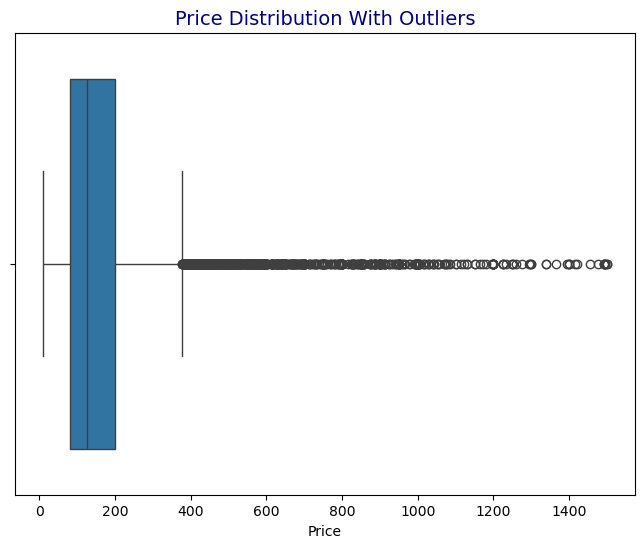

In [18]:
# identifying outlier in price

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='price')
plt.title("Price Distribution With Outliers", fontsize = 14, color='darkblue')
plt.xlabel('Price')
plt.show()

### insight

Most listings are priced at the lower end, but the presence of numerous extreme outliers at very high prices indicates a 
skewed distribution driven by a small number of luxury listings.


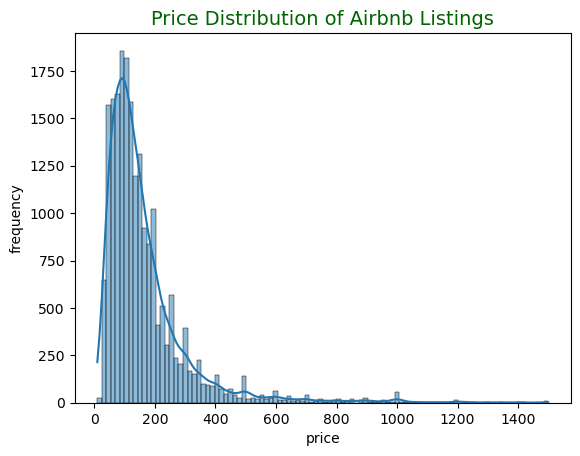

In [19]:
# # Price Distribution

plt.title('Price Distribution of Airbnb Listings', fontsize = 14, color = 'darkgreen')
plt.Figure(figsize=(10,6))
sns.histplot(data=df, x='price', bins=100, kde=True)
plt.ylabel('frequency')
plt.show()

### Insight

The price distribution is highly right-skewed.  
Most Airbnb listings fall in the lower price range, while a small number
of luxury listings have very high prices.

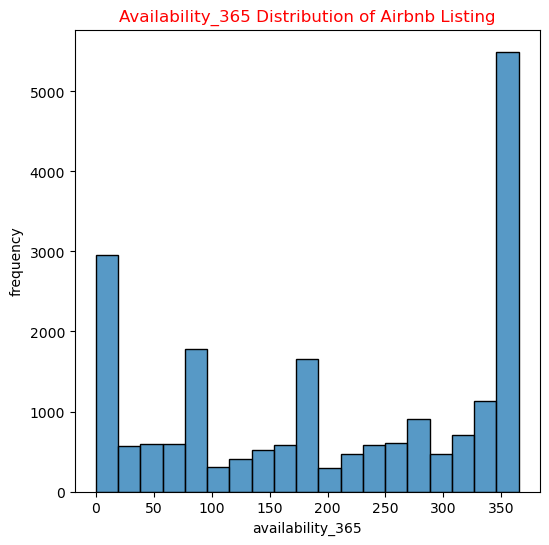

In [20]:
# Availability Distribution

plt.figure(figsize=(6, 6))
sns.histplot(data=df, x='availability_365')
plt.title('Availability_365 Distribution of Airbnb Listing', color='red')
plt.ylabel('frequency')
plt.show()

### insight

Airbnb listings in New York tend to cluster at the extremes of availability — many are either rarely available (close to 0 days) or always available (365 days), with fewer listings offering moderate availability.
This version is short, clear, and directly communicates the key takeaway without extra detail.
Would you like me to also craft a one‑line business implication (e.g., what this means for hosts or platform strategy) so it’s even more actionable?


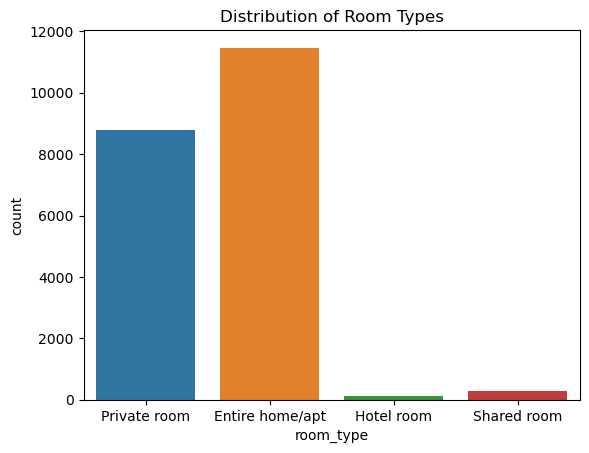

In [21]:
# Room type distribution

plt.Figure(figsize=(8,6))
sns.countplot(x='room_type', data=df, hue='room_type')
plt.title('Distribution of Room Types')
plt.show()

### Insight

The dataset is dominated by entire home/apartment listings, suggesting that most hosts prefer renting out their entire property
rather than just a portion. Private rooms are the second most common option,
while hotel rooms and shared rooms are relatively rare.


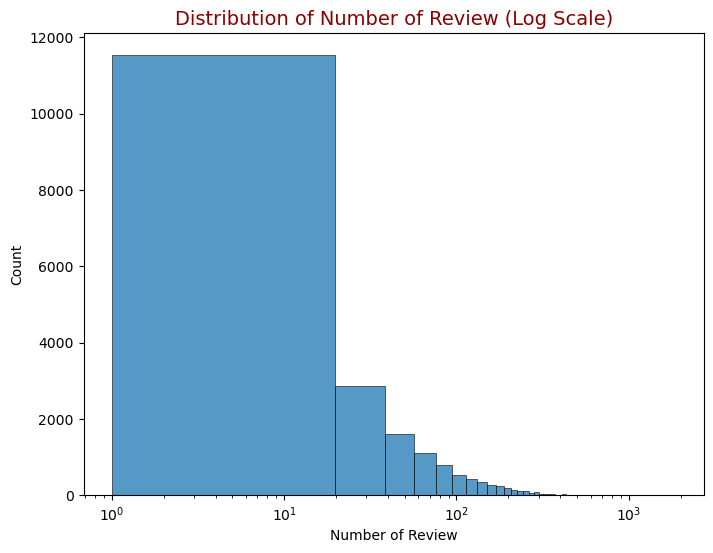

In [22]:
# number_of_reviews distribution

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='number_of_reviews', bins=100,kde=False)
plt.title("Distribution of Number of Review (Log Scale)", fontsize = 14, color = 'darkred')
plt.xlabel("Number of Review")
plt.ylabel("Count")
plt.xscale('log')
plt.show()

### insight

Most Airbnb listings in New York receive very few reviews, while a small number of highly popular 
listings accumulate hundreds of reviews, creating a strongly skewed distribution.


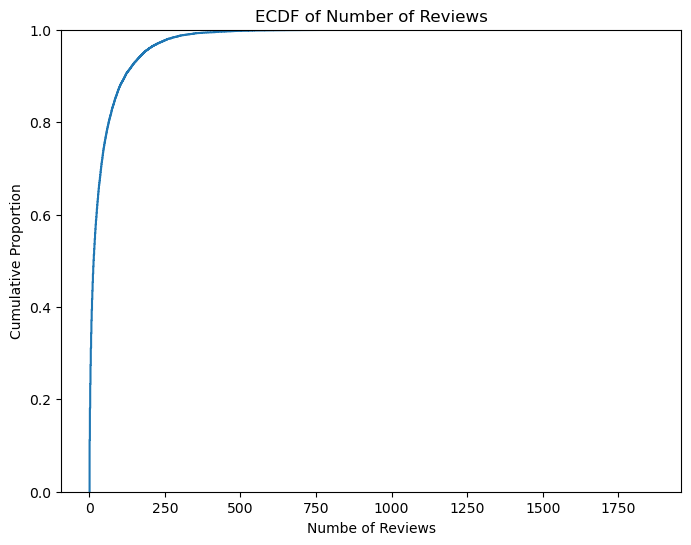

In [23]:
# ECDF plot 

plt.figure(figsize=(8,6))
sns.ecdfplot(data=df, x='number_of_reviews')
plt.title("ECDF of Number of Reviews", fontsize = 12)
plt.xlabel('Numbe of Reviews')
plt.ylabel('Cumulative Proportion')
plt.show()

### insight

The ECDF reveals that most listings accumulate very few reviews — the curve rises steeply at the beginning, showing that a large share of hosts have fewer than 10–20 reviews. Beyond that, the curve flattens, meaning only a small fraction of listings gather hundreds of reviews. This confirms a highly skewed engagement pattern, where popularity is concentrated among a limited set of listings.


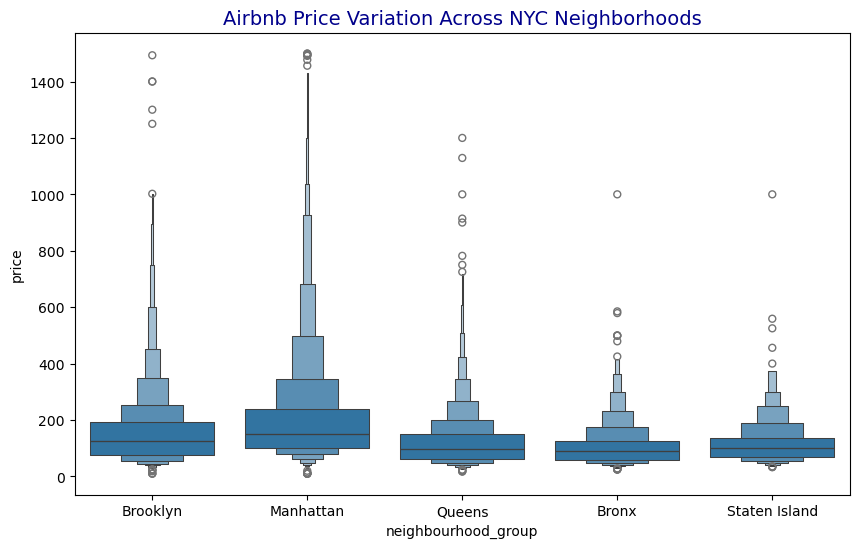

In [24]:
# Price by Neighborhood

plt.figure(figsize=(10,6))
sns.boxenplot(data=df, x='neighbourhood_group', y='price')
plt.title("Airbnb Price Variation Across NYC Neighborhoods", fontsize=14, color='darkblue')
plt.show()

### insight

Airbnb prices in New York vary sharply by location: Manhattan listings are the most expensive with wide variation and many luxury outliers, while Brooklyn and Queens are moderately priced. Bronx and Staten Island remain the most affordable, showing that neighborhood choice is the strongest driver of price differences.
Business Implication


In [25]:
# Average price by neighbourhood_group

df.groupby('neighbourhood_group')['price'].mean()

neighbourhood_group
Bronx            107.990506
Brooklyn         155.138317
Manhattan        204.146014
Queens           121.681939
Staten Island    118.780069
Name: price, dtype: float64

**Bi Variable Analysis**

* One variable depenency in another variable
* Bi = One column analysis with another column
*  How one column is depending on other column 

In [26]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='object')

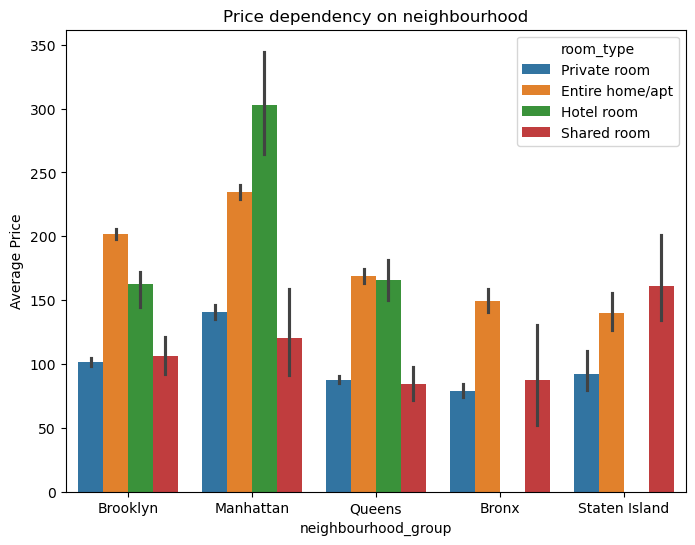

In [27]:
# Price dependency on neighbourhood

plt.figure(figsize=(8,6))
sns.barplot(data=df, x='neighbourhood_group', y= 'price', hue='room_type')
plt.title('Price dependency on neighbourhood')
plt.ylabel("Average Price")
plt.show()

### insight

Prices vary strongly by neighborhood and room type — Manhattan has the highest prices across all room types, especially hotel rooms,
while Bronx and Staten Island remain the most affordable.
This shows that location and room type together drive Airbnb pricing in New York.


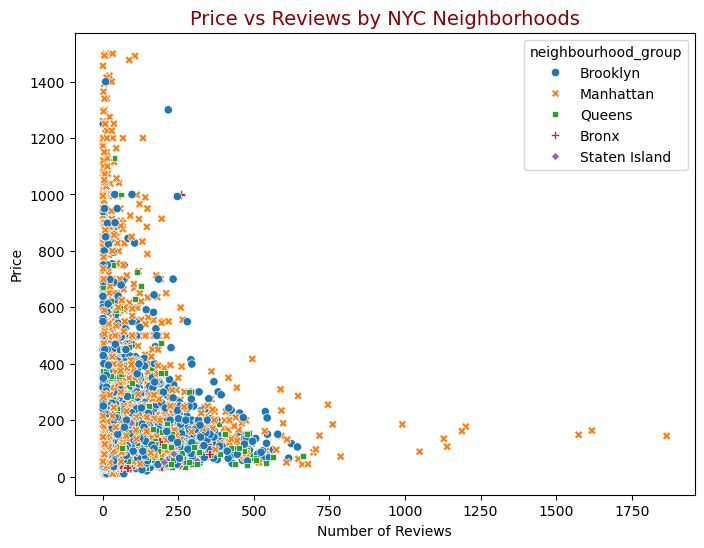

In [28]:
# number of review and price relationship

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='number_of_reviews', y='price', 
                hue='neighbourhood_group', style='neighbourhood_group')
plt.title('Price vs Reviews by NYC Neighborhoods', fontsize=14, color='darkred')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

### insight

Listings with higher prices generally attract fewer reviews, while affordable listings gather more. Manhattan shows the widest spread of high prices, confirming that both location and affordability influence guest engagement.

In [29]:
df.dtypes

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                                int64
baths                              object
dtype: object

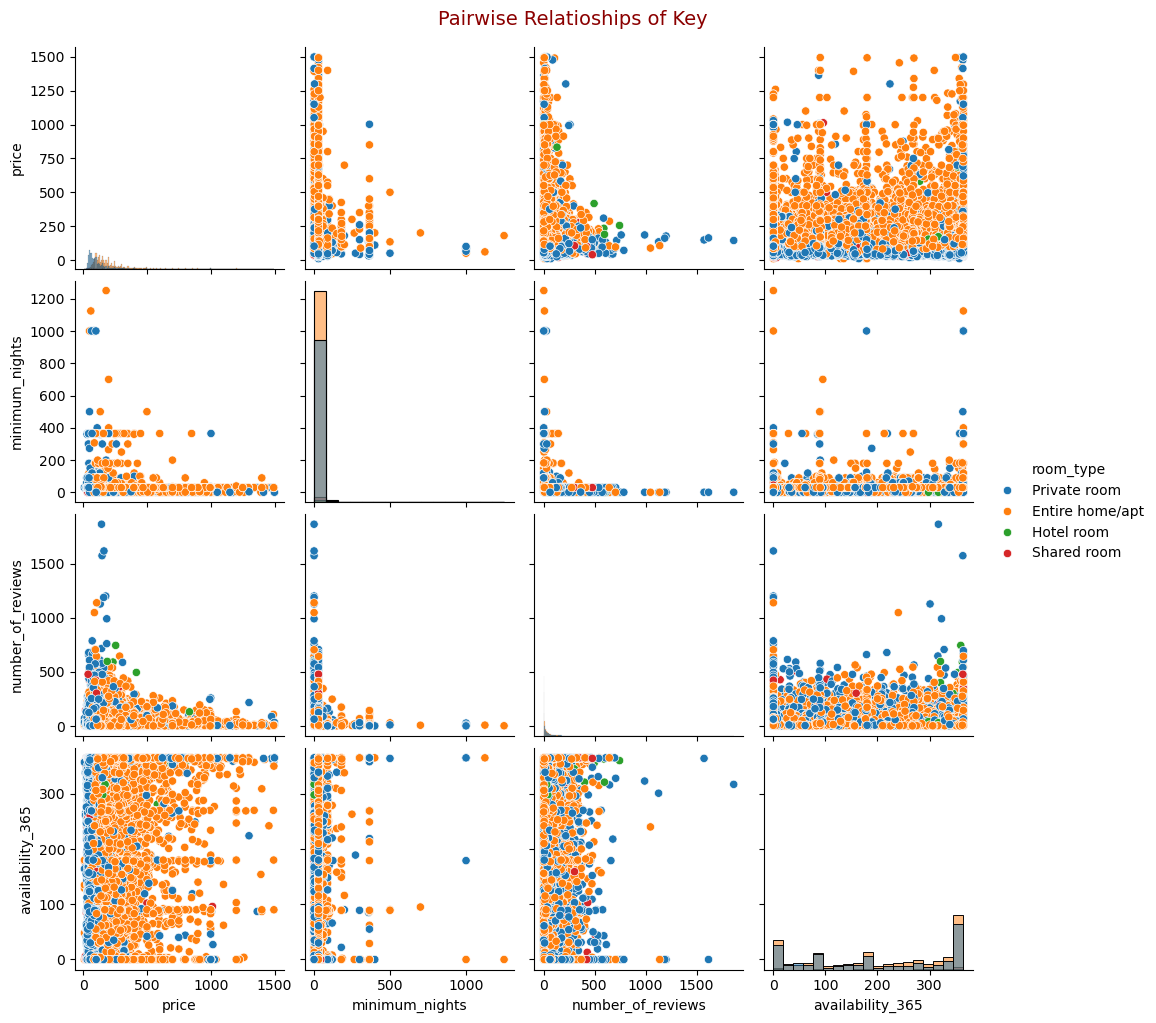

In [30]:
# Pairwise Relatioship Between Every Column

plt.Figure(figsize=(8,6))

sns.pairplot(data=df, vars=['price', 'minimum_nights', 'number_of_reviews', 'availability_365'], hue='room_type', diag_kind='hist')
plt.suptitle('Pairwise Relatioships of Key', y=1.02, fontsize=14, color='darkred')
plt.show()

### insight

The pairplot shows that price and minimum nights are highly skewed with many outliers, while number of reviews and availability_365 cluster at lower values. Room type differences are visible — entire homes/apts dominate higher prices, while private rooms cluster at lower price ranges.

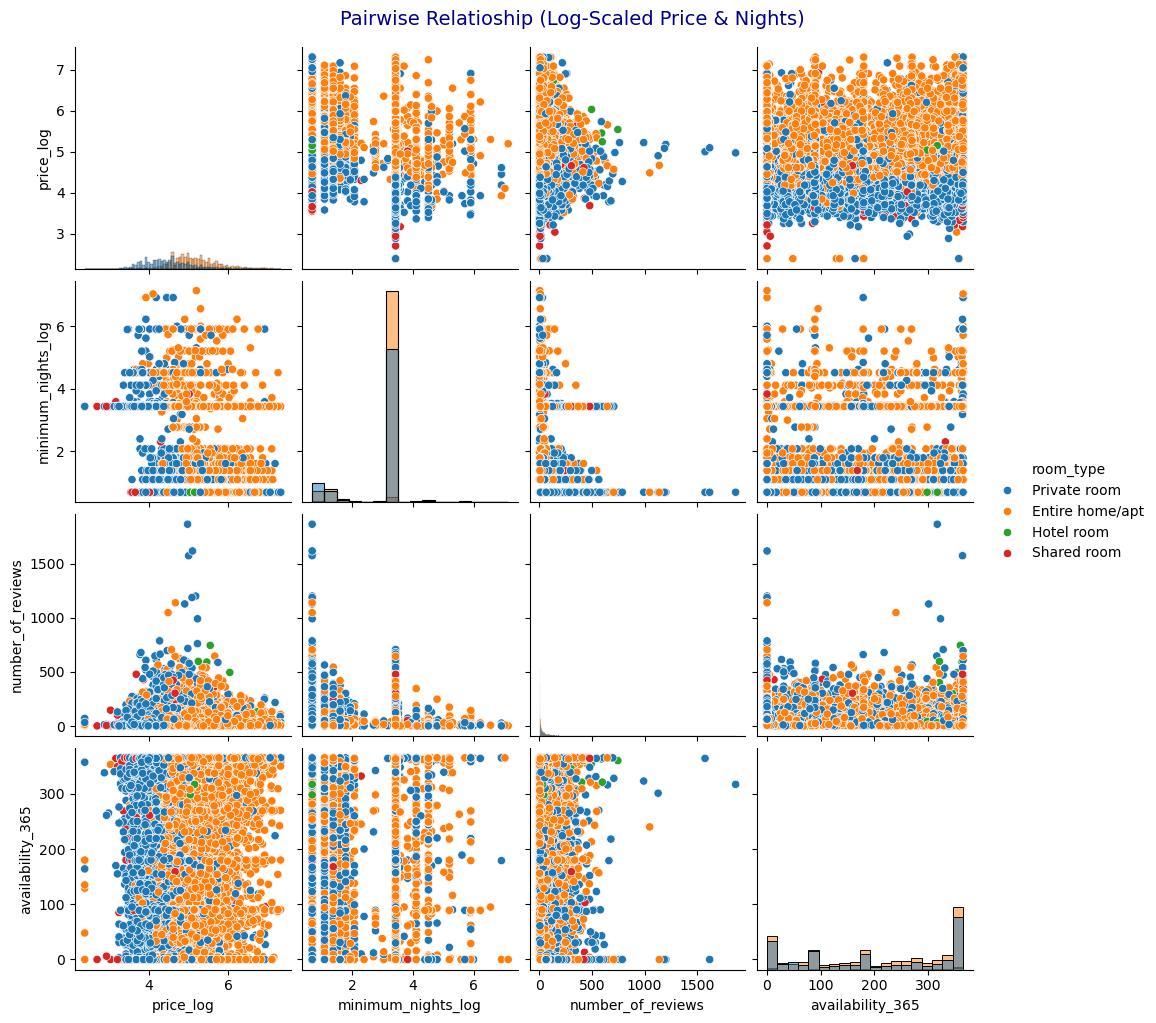

In [31]:
import numpy as np

df_log = df.copy()
df_log['price_log'] = np.log1p(df['price'])

df_log['minimum_nights_log'] = np.log1p(df['minimum_nights'])

sns.pairplot(data=df_log, vars=['price_log', 'minimum_nights_log', 'number_of_reviews', 'availability_365'],
             hue='room_type',
             diag_kind='hist')
plt.suptitle("Pairwise Relatioship (Log-Scaled Price & Nights)", y=1.02, fontsize=14, color='darkblue')
plt.show()

### insight

With log scaling, the pairplot shows that:
- Entire homes/apts dominate higher price ranges, even after transformation.
- Private rooms cluster at lower prices and shorter stays.
- Number of reviews remains concentrated at low values, confirming limited engagement for most listings.
- Availability is polarized (either rarely available or year-round).


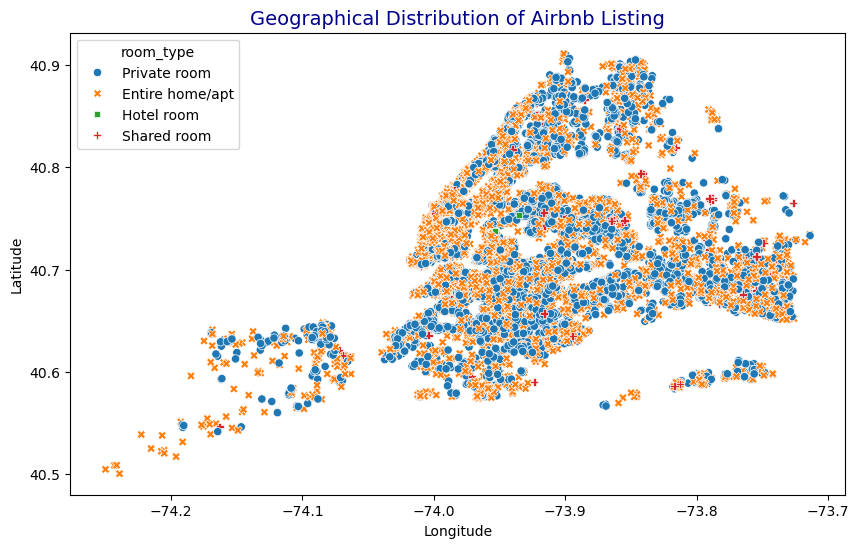

In [32]:
# Geographical Distribution of AirBnb Listing

plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='longitude', y='latitude', hue='room_type', style='room_type')
plt.title("Geographical Distribution of Airbnb Listing", fontsize = 14, color = 'darkblue')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### insight

Airbnb listings are concentrated in Manhattan and Brooklyn, with entire homes/apts dominating central areas, while private rooms spread more widely across boroughs. This shows that room type availability varies by location, reflecting both demand and housing patterns in New York City.


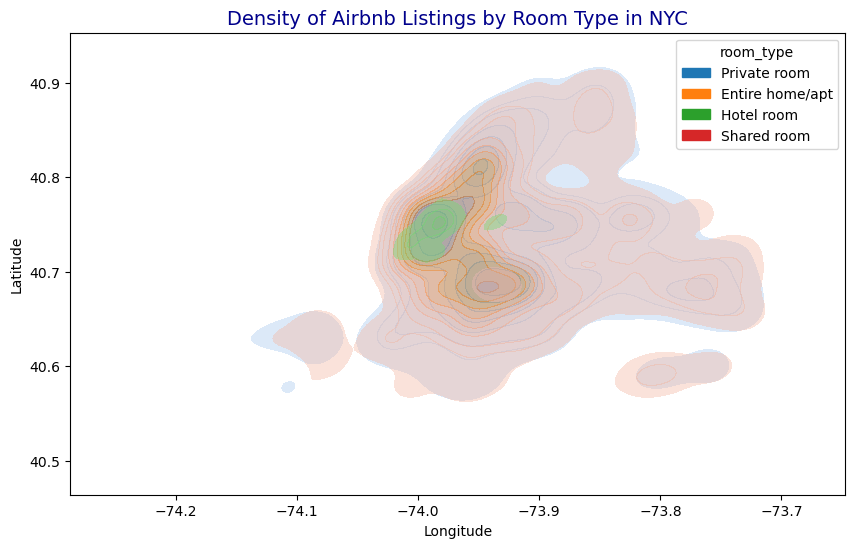

In [33]:
# Kdeplot for smoother geographic heatmaps

plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x='longitude', y='latitude', hue='room_type', fill=True, alpha=0.4, thresh=0.05)
plt.title("Density of Airbnb Listings by Room Type in NYC", fontsize=14, color='darkblue')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### insight

Airbnb listings are densely concentrated in Manhattan and Brooklyn, with far fewer in outer boroughs. Entire homes/apts dominate the central hotspots, while private rooms spread more widely across the city. Hotel rooms appear in limited clusters, confirming that room type distribution reflects both demand and housing patterns across NYC.




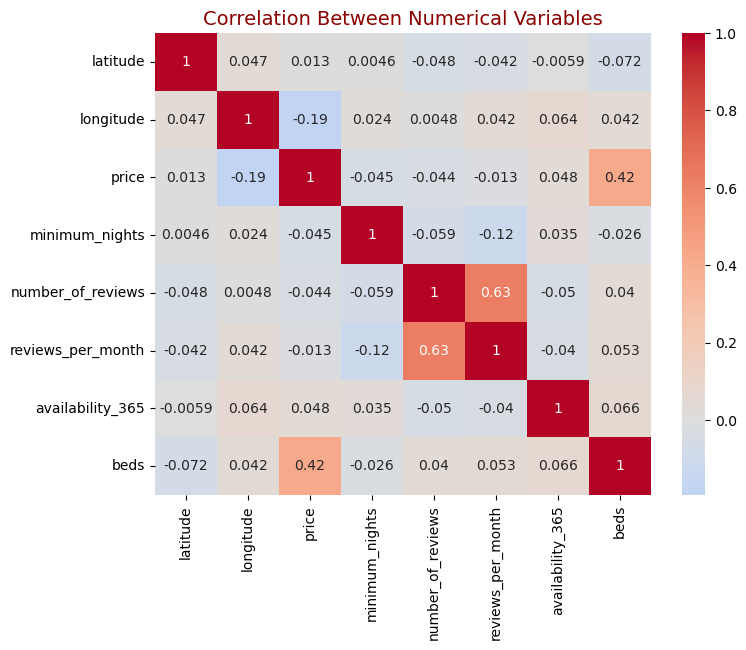

In [34]:
# heat map - correlation of one variable with other for numerical column
# .corr() - a single column make the relationship with all the others column 

corr = df[['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'beds']].corr()

corr

plt.figure(figsize=(8,6))
sns.heatmap(data=corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Between Numerical Variables", fontsize = 14, color = 'darkred')

plt.show()

### insight

- Number of reviews and reviews per month show a strong positive correlation, meaning listings with more reviews tend to receive them more frequently.
- Price and beds have a moderate positive correlation, confirming that larger listings generally cost more.
- Other variables (like latitude/longitude vs price) show weak or negligible correlations, suggesting location alone doesn’t directly determine price — instead, room type and    neighborhood context matter more.


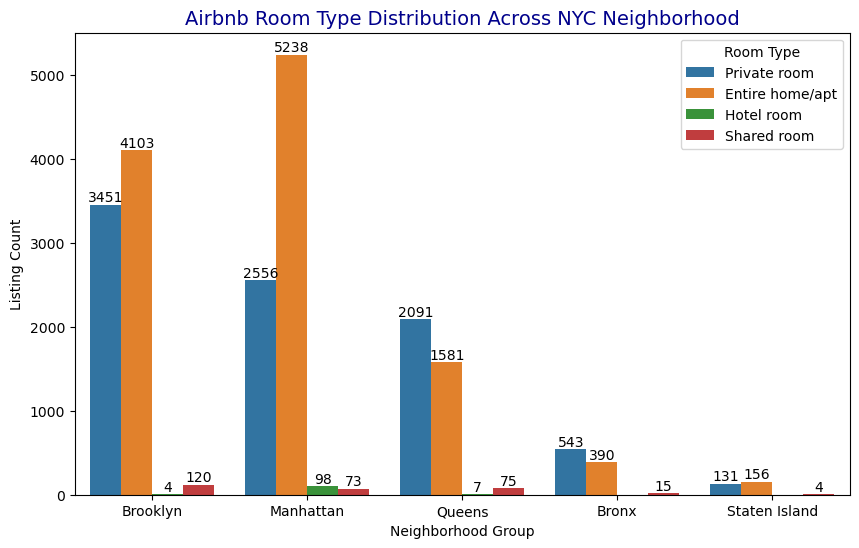

In [51]:
# overall distribution of listings by room type and neighborhood group.

plt.figure(figsize=(10,6))

ax = sns.countplot(data=df, x='neighbourhood_group', hue='room_type')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Airbnb Room Type Distribution Across NYC Neighborhood", fontsize = 14, color='darkblue')
plt.xlabel("Neighborhood Group")
plt.ylabel("Listing Count")
plt.legend(title="Room Type")
plt.show()

### insight

Manhattan and Brooklyn dominate Airbnb supply, with entire homes/apts leading in Manhattan and private rooms more common in Brooklyn and Queens. Bronx and Staten Island have far fewer listings overall, showing that Airbnb activity is concentrated in central boroughs and shaped by room type preferences.


### Feature Engineering


Feature engineering involves creating new features from existing
data to improve analysis and extract deeper insights from the dataset.

In [36]:
# Create new column which give us per bed price 
# ['price per bed'] 

df['price_per_bed'] = df['price']/df['beds']


C:\Users\HP\AppData\Local\Temp\ipykernel_14352\4000552708.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_per_bed'] = df['price']/df['beds']


In [37]:
# group by 

print(df.groupby('neighbourhood_group')['price'].mean())

print()

print('neighbourhood group average price per bed')
print('---------------------')
print(df.groupby('neighbourhood_group')['price_per_bed'].mean())

neighbourhood_group
Bronx            107.990506
Brooklyn         155.138317
Manhattan        204.146014
Queens           121.681939
Staten Island    118.780069
Name: price, dtype: float64

neighbourhood group average price per bed
---------------------
neighbourhood_group
Bronx             74.713639
Brooklyn          99.788493
Manhattan        138.708057
Queens            76.336210
Staten Island     67.728101
Name: price_per_bed, dtype: float64


In [38]:
# Create Price Category Column 

df['price_category'] = pd.cut(df['price'], 
                              bins=[0,100,300,600,1000,10000],
                              labels=['Budget', 'Standard', 'Premium', 'Luxury', 'Ultra Luxury']
                              )


C:\Users\HP\AppData\Local\Temp\ipykernel_14352\1613285811.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_category'] = pd.cut(df['price'],


In [39]:
df[['price', 'price_category']].head()

,price,price_category
0,55.0,Budget
1,144.0,Standard
2,187.0,Standard
3,120.0,Standard
4,85.0,Budget


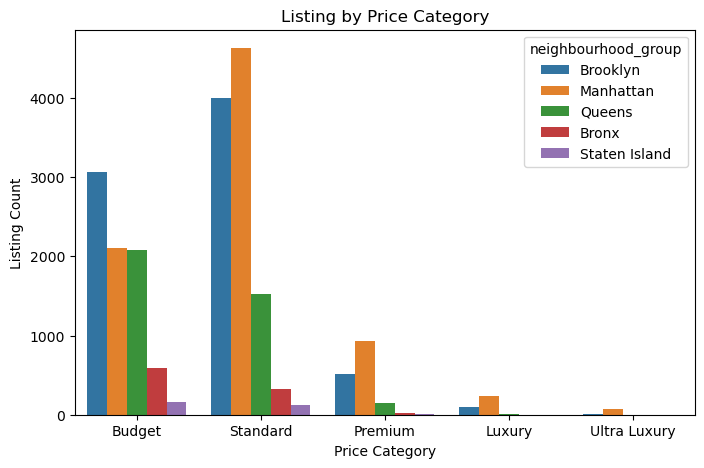

In [40]:
# Visualize it

plt.figure(figsize=(8,5))
sns.countplot(x='price_category', data=df, hue='neighbourhood_group')
plt.title("Listing by Price Category")
plt.xlabel('Price Category')
plt.ylabel('Listing Count')
plt.show()

### insight
Most Airbnb listings in New York fall into the Budget and Standard categories, especially in Brooklyn and Queens. Luxury and Ultra Luxury listings are concentrated in Manhattan, highlighting that affordability drives supply in outer boroughs, while premium pricing is centered in Manhattan.


In [41]:
# Create Column demand Category

df['demand_level'] = pd.cut(df['reviews_per_month'],
                            bins=[0,1,3,6,20],
                            labels=['Low', 'Medium', 'High', 'Very High']
                            )

C:\Users\HP\AppData\Local\Temp\ipykernel_14352\3419710374.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_level'] = pd.cut(df['reviews_per_month'],


In [42]:
df[['reviews_per_month','demand_level']]

,reviews_per_month,demand_level
0,0.03,Low
1,0.24,Low
2,1.67,Medium
3,1.38,Medium
4,0.24,Low
...,...,...
20765,1.81,Medium
20766,0.48,Low
20767,2.09,Medium
20768,0.91,Low


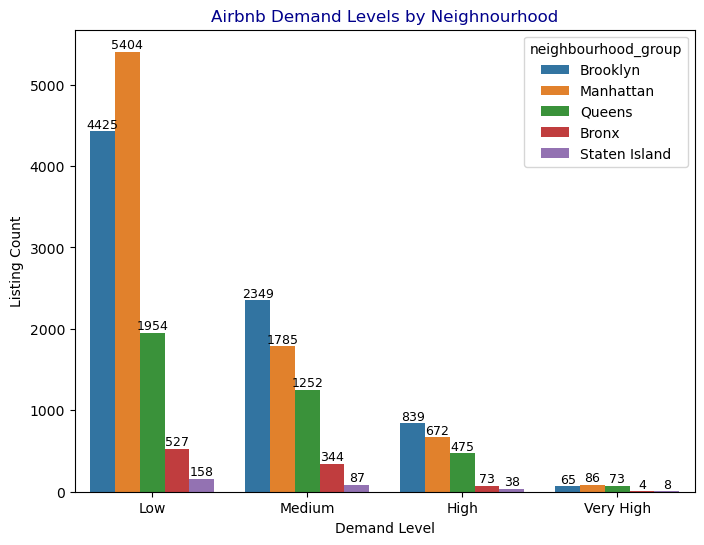

In [43]:
# visualize this demand level chart

plt.figure(figsize=(8,6))
ax= sns.countplot(data=df, x='demand_level', hue='neighbourhood_group')
plt.title('Airbnb Demand Levels by Neighnourhood', color='darkblue')
plt.xlabel('Demand Level')
plt.ylabel('Listing Count')

# add values on top of bars

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize = 9)
plt.show()

### insight

Most listings fall into the Low and Medium demand categories, showing that the majority of properties receive only a few reviews per month. Brooklyn leads in Medium and High demand listings, while Manhattan dominates in overall volume but with many low‑demand properties. Very High demand listings are rare across all boroughs, and Staten Island consistently shows the lowest demand, confirming that location strongly shapes listing popularity and engagement.


In [44]:
# Create availability level column

df['availability_level'] = pd.cut(df['availability_365'],
                                  bins=[0,50,150,300,365],
                                  labels=['Low Availability', 'Moderate', 'High', 'Very High']                                  
                                  )

C:\Users\HP\AppData\Local\Temp\ipykernel_14352\3789173742.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['availability_level'] = pd.cut(df['availability_365'],


In [45]:
df[['availability_365', 'availability_level']]

,availability_365,availability_level
0,0.0,NaN
1,364.0,Very High
2,343.0,Very High
3,363.0,Very High
4,335.0,Very High
...,...,...
20765,157.0,High
20766,0.0,NaN
20767,0.0,NaN
20768,363.0,Very High


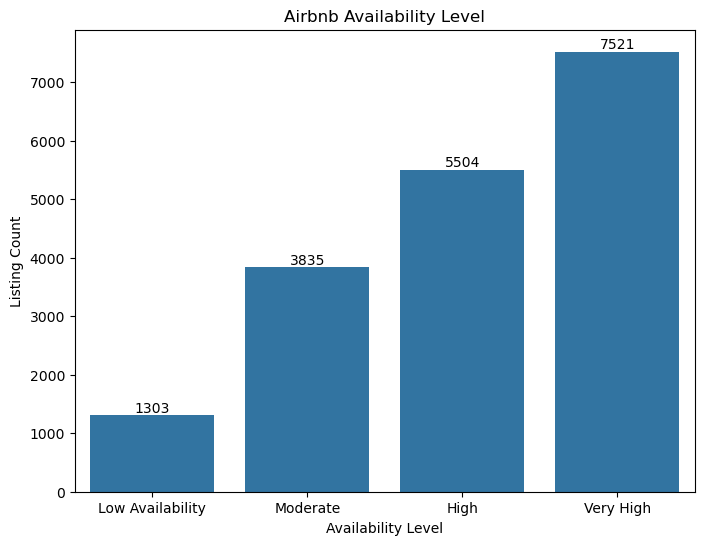

In [46]:
# Visualize this 

plt.figure(figsize=(8,6))

ax = sns.countplot(x='availability_level', data=df)
plt.title("Airbnb Availability Level")
plt.xlabel('Availability Level')
plt.ylabel('Listing Count')

# Show values on top bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()

### insight

Most listings in NYC fall into the High and Very High availability categories, meaning a large share of properties are open for booking most of the year. Fewer listings are in the Low availability group, showing that short‑term or seasonal rentals are less common. This highlights that Airbnb supply in NYC is largely year‑round, especially in central boroughs.


### 🏁 Final Conclusion
This analysis of New York City Airbnb listings reveals a clear market structure shaped by price, demand, and availability. Most listings are concentrated in the Budget and Standard categories, especially in Brooklyn and Queens, while Luxury and Ultra Luxury properties cluster in Manhattan, reflecting affordability differences across boroughs. Demand levels show that the majority of listings attract low to medium engagement, with only a small fraction achieving very high popularity — again concentrated in central areas. Finally, availability patterns highlight that most properties are open year‑round, reinforcing Airbnb’s role as a consistent supply channel in NYC. Together, these insights show that outer boroughs drive affordability and moderate demand, while Manhattan dominates premium supply and high‑demand activity, offering a balanced view of how Airbnb operates across the city.

👉 This ties all your engineered features (price category, demand level, availability level) into one cohesive story, making your project end with impact and clarity.
Would you like me to also help you frame this conclusion into a short executive summary (3–4 bullet points) so it’s presentation‑ready for stakeholders?


## Key Insight from Analysis

## Business Questions & Answers
1. Which neighborhoods have the highest number of Airbnb listings?
-  Brooklyn has the highest number of listings, followed by Manhattan.

2. How does price vary across different room types?
- Entire homes/apts are the most expensive, while private and shared rooms are cheaper.


3. Which neighborhoods have the most expensive listings?
- Manhattan has the most expensive listings compared to other boroughs.

4. What factors influence Airbnb listing prices?
- Location, room type, and number of beds strongly influence prices.

5. Which areas have the highest demand based on reviews?
- Manhattan and Brooklyn have the highest demand, with more reviews per month than other boroughs.

6. Which availability level has the most listings?
- Most listings fall into the High and Very High availability categories, showing year‑round supply.

7. Which demand level dominates across NYC?
- The majority of listings are in the Low and Medium demand categories, with only a small share achieving very high demand.

8. How do price categories vary by borough?
- Budget and Standard listings dominate Brooklyn and Queens, while Luxury and Ultra Luxury listings are concentrated in Manhattan.



## Business Recommendations

- Hosts in outer boroughs should focus on affordability and visibility strategies, since most listings there are budget or standard with moderate demand.

- Manhattan hosts can leverage premium pricing and year‑round availability to maximize revenue, as demand and luxury supply are concentrated there.

- Hosts in Manhattan can charge higher prices due to strong demand.

- New hosts entering the market may consider offering private rooms,
  as this category dominates the platform.

- Pricing strategy should consider neighborhood and room type
  to remain competitive in the market.


## Feature Correlation Analysis

Correlation analysis helps identify relationship between numerical feature in the dataset.
A heatmap visualization allows us to quickly understand which variable are positively or
negatively related.

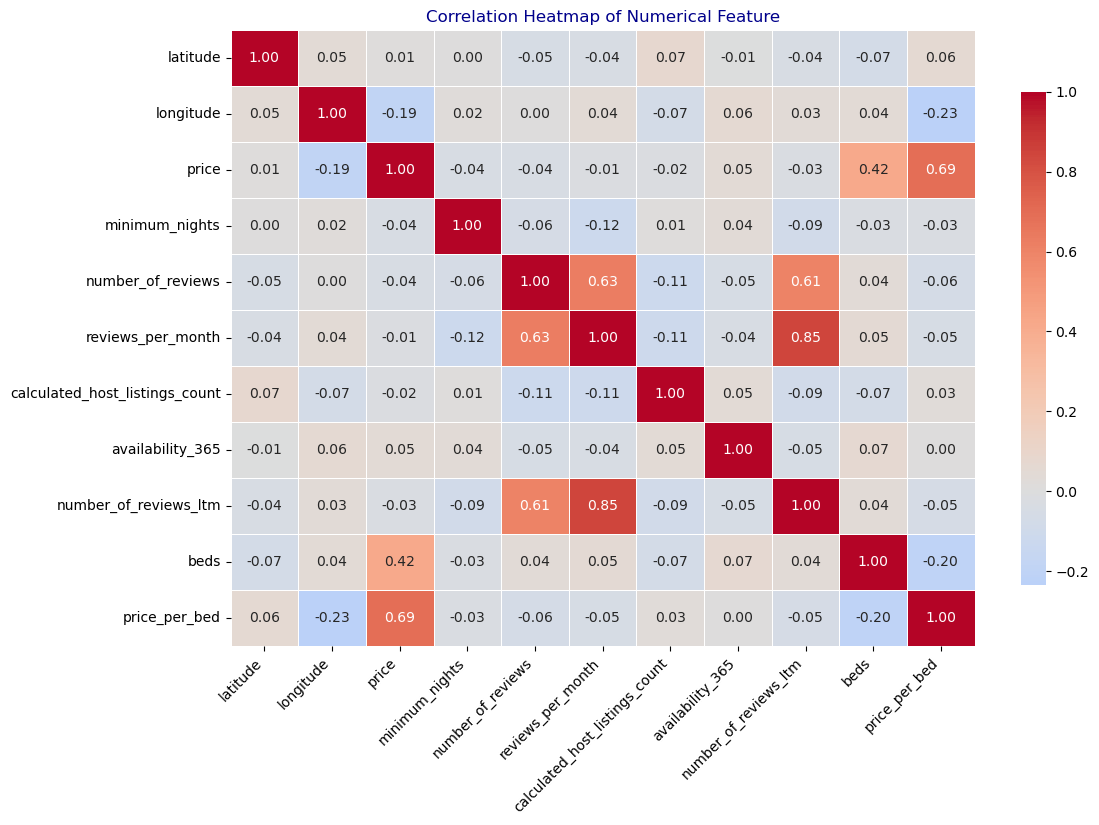

In [47]:
plt.figure(figsize=(12,8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix,\
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            center=0,
            fmt=".2f",
            cbar_kws={'shrink':0.8}
            )

plt.title("Correlation Heatmap of Numerical Feature", color='darkblue')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation = 0)
plt.show()

### insight for this correlation heatmap

- Price and price_per_bed have a strong positive correlation, meaning larger listings cost more per bed.
- Reviews_per_month and number_of_reviews_ltm are highly correlated, confirming they measure similar demand.
- Beds and price show a moderate positive correlation, while most other variables (like latitude/longitude) have weak or negligible relationships.


### Business insight for this 

The heatmap shows that price is most influenced by room size (beds) and price per bed, while reviews_per_month and number_of_reviews_ltm are strongly related, confirming they capture similar demand. Other variables like latitude and longitude have weak correlations, meaning location alone doesn’t determine price — size and demand indicators matter more.


In [48]:
df.to_csv("clean_airbnb_data.csv", index=False)